# Walmart Sales Analysis & Forecasting

## Objective

Analyze Walmart sales data to:

- Identify sales trends
- Find top performing stores
- Measure holiday impact
- Analyze economic factors
- Segment stores
- Forecast future sales

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Prophet

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("Walmart_Sales.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.shape

(6435, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

df['Month_Name'] = df['Date'].dt.month_name()

df['Quarter'] = df['Date'].dt.quarter

In [ ]:
df['Season'] = df['Month'].map({
    12:'Winter',
    1:'Winter',
    2:'Winter',
    3:'Spring',
    4:'Spring',
    5:'Spring',
    6:'Summer',
    7:'Summer',
    8:'Summer',
    9:'Fall',
    10:'Fall',
    11:'Fall'
})

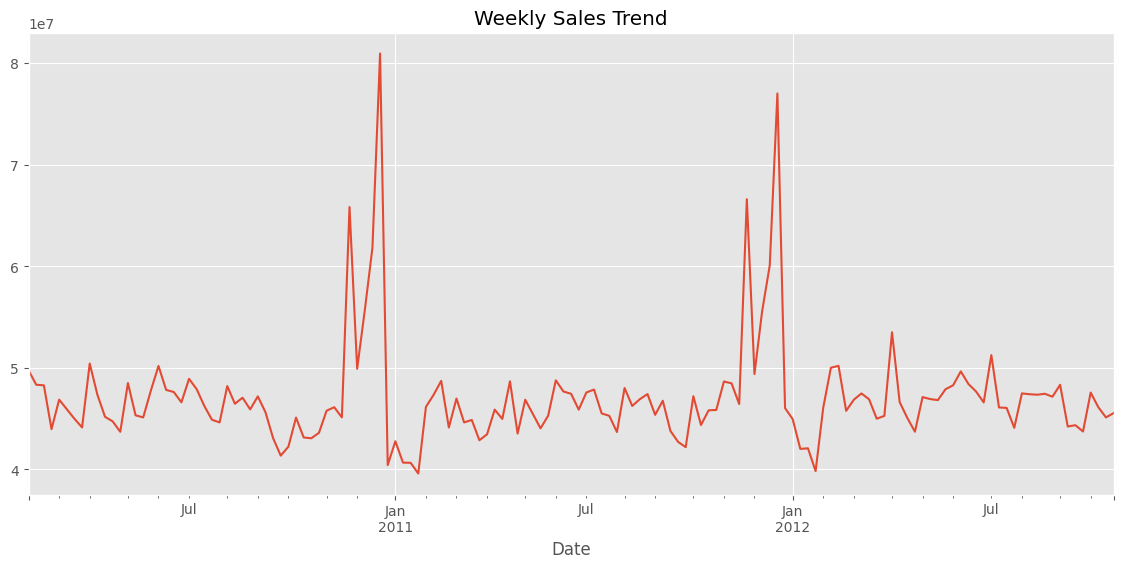

In [ ]:
weekly_sales = df.groupby(
    'Date'
)['Weekly_Sales'].sum()

plt.figure(figsize=(14,6))

weekly_sales.plot()

plt.title("Weekly Sales Trend")
plt.show()

In [ ]:
monthly_sales = df.groupby(
    ['Year','Month']
)['Weekly_Sales'].sum().reset_index()

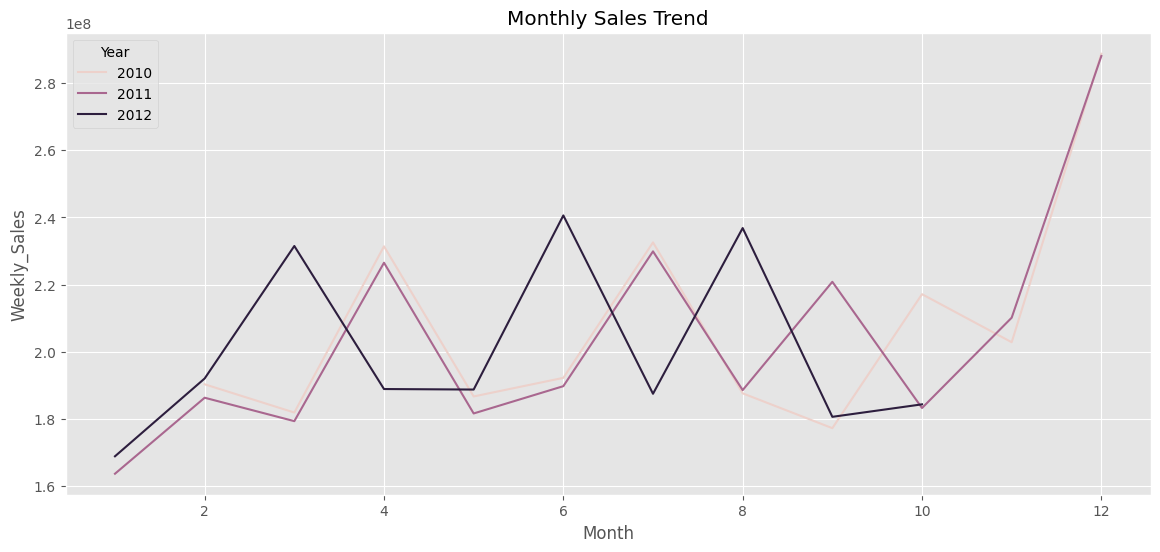

In [ ]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Weekly_Sales',
    hue='Year'
)

plt.title("Monthly Sales Trend")
plt.show()

In [ ]:
store_sales = df.groupby(
    'Store'
)['Weekly_Sales'].sum().sort_values(
    ascending=False
)

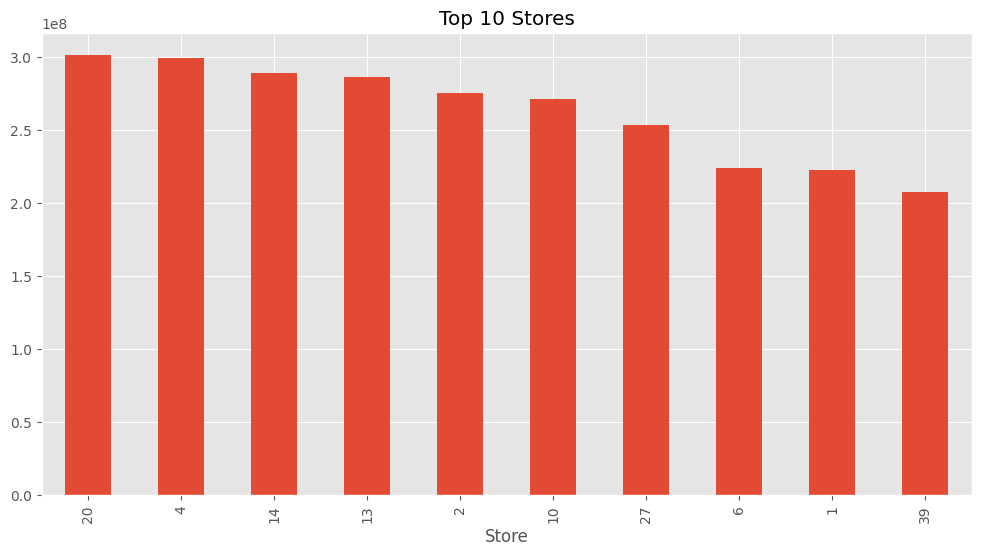

In [ ]:
plt.figure(figsize=(12,6))

store_sales.head(10).plot(
    kind='bar'
)

plt.title("Top 10 Stores")
plt.show()

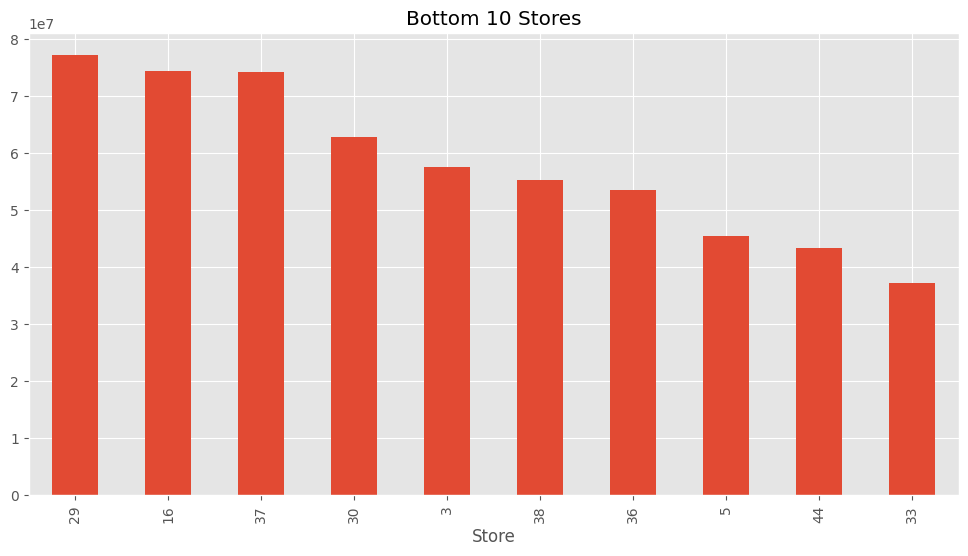

In [ ]:
plt.figure(figsize=(12,6))

store_sales.tail(10).plot(
    kind='bar'
)

plt.title("Bottom 10 Stores")
plt.show()

In [ ]:
holiday_avg = df[
    df['Holiday_Flag']==1
]['Weekly_Sales'].mean()

non_holiday_avg = df[
    df['Holiday_Flag']==0
]['Weekly_Sales'].mean()

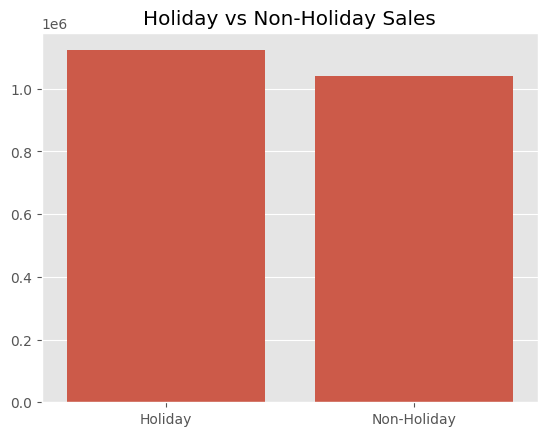

In [ ]:
sns.barplot(
    x=['Holiday','Non-Holiday'],
    y=[holiday_avg, non_holiday_avg]
)

plt.title(
    "Holiday vs Non-Holiday Sales"
)

plt.show()

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
holiday = df[
    df['Holiday_Flag']==1
]['Weekly_Sales']

nonholiday = df[
    df['Holiday_Flag']==0
]['Weekly_Sales']

In [ ]:
t,p = ttest_ind(
    holiday,
    nonholiday
)

print("P Value:",p)

P Value: 0.003078699263818616


In [ ]:
if p < 0.05:
    print("Significant Difference")
else:
    print("No Significant Difference")

Significant Difference


In [ ]:
season_sales = df.groupby(
    'Season'
)['Weekly_Sales'].sum()

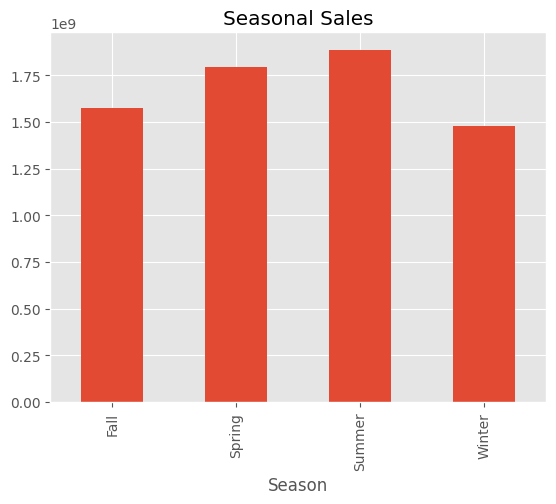

In [ ]:
season_sales.plot(
    kind='bar'
)

plt.title("Seasonal Sales")
plt.show()

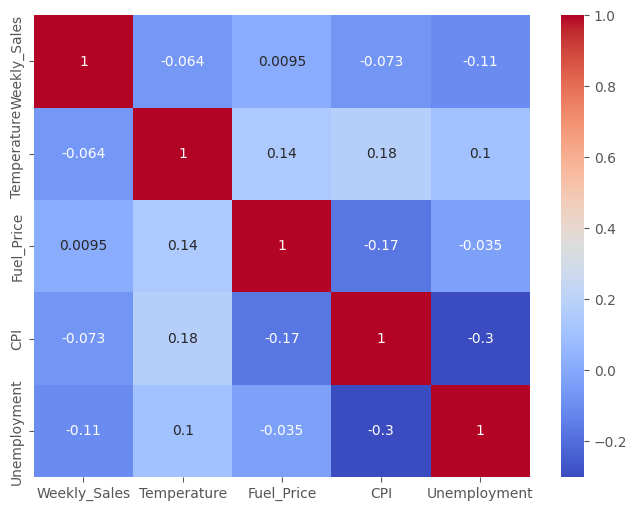

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            'Weekly_Sales',
            'Temperature',
            'Fuel_Price',
            'CPI',
            'Unemployment'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

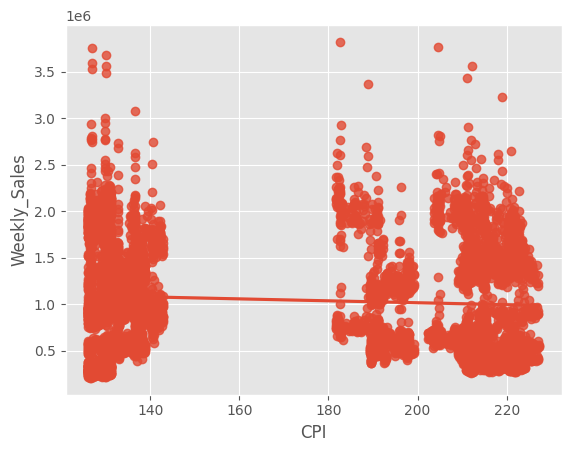

In [ ]:
sns.regplot(
    x='CPI',
    y='Weekly_Sales',
    data=df
)

plt.show()

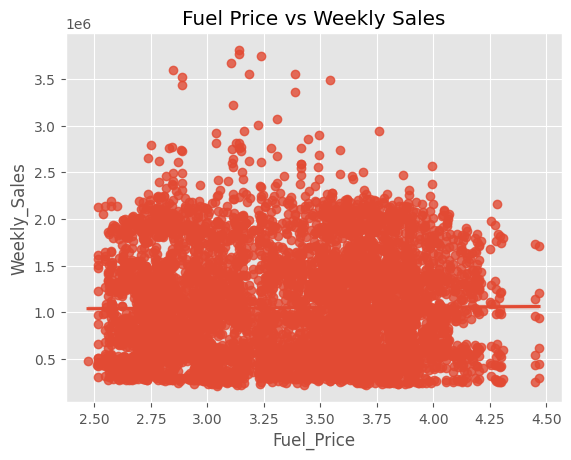

In [ ]:
sns.regplot(
    x='Fuel_Price',
    y='Weekly_Sales',
    data=df
)

plt.title("Fuel Price vs Weekly Sales")

plt.show()

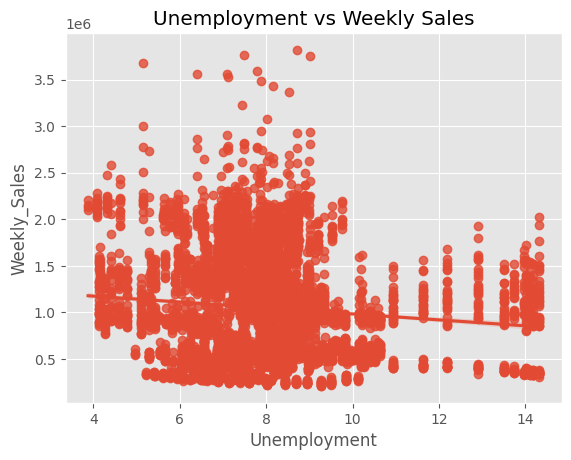

In [ ]:
sns.regplot(
    x='Unemployment',
    y='Weekly_Sales',
    data=df
)

plt.title("Unemployment vs Weekly Sales")

plt.show()

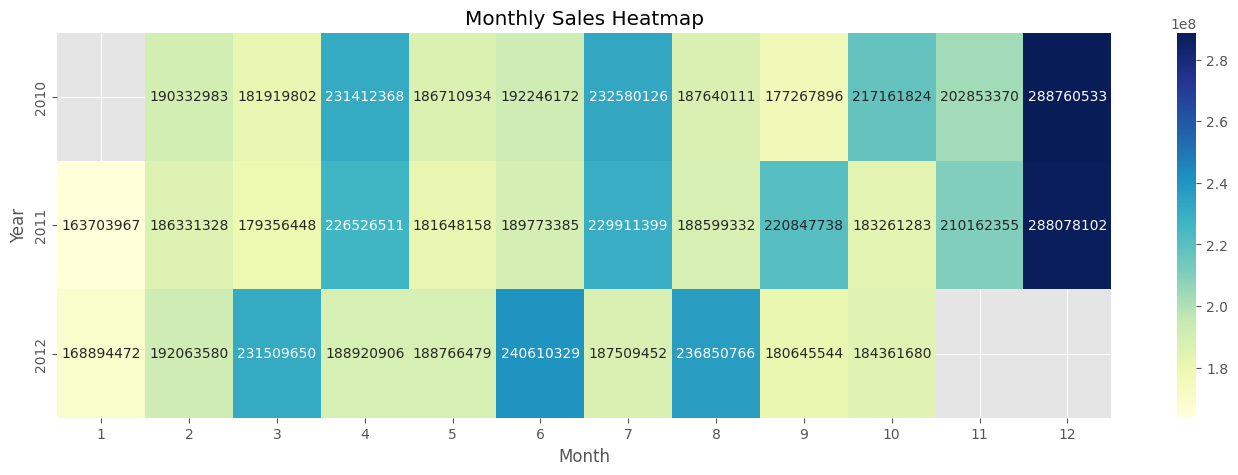

In [ ]:
pivot = pd.pivot_table(
    df,
    values='Weekly_Sales',
    index='Year',
    columns='Month',
    aggfunc='sum'
)

plt.figure(figsize=(17,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title("Monthly Sales Heatmap")

plt.show()

In [ ]:
store_features = df.groupby(
    'Store'
).agg({
    'Weekly_Sales':'mean',
    'CPI':'mean',
    'Fuel_Price':'mean',
    'Unemployment':'mean'
})

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(
    store_features
)

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

store_features['Cluster'] = (
    kmeans.fit_predict(X)
)

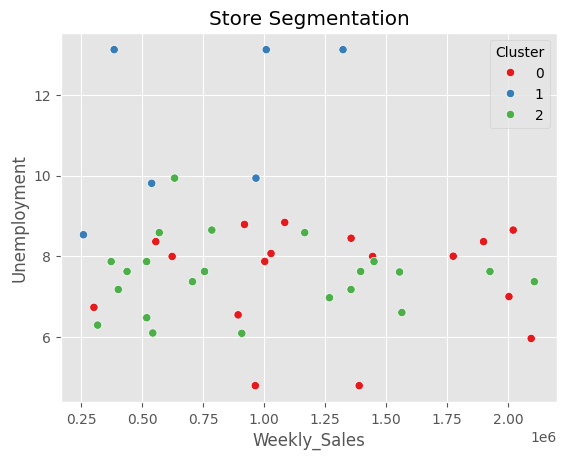

In [ ]:
sns.scatterplot(
    data=store_features,
    x='Weekly_Sales',
    y='Unemployment',
    hue='Cluster',
    palette='Set1'
)

plt.title("Store Segmentation")

plt.show()

In [ ]:
!pip install prophet

In [ ]:
forecast_df = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

forecast_df.columns = ['ds','y']

forecast_df.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [ ]:
from prophet import Prophet

model = Prophet()

model.fit(forecast_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(
    periods=52,
    freq='W'
)

future.tail()

,ds
190,2013-09-22
191,2013-09-29
192,2013-10-06
193,2013-10-13
194,2013-10-20


In [ ]:
forecast = model.predict(future)

forecast[['ds','yhat']].tail()

,ds,yhat
190,2013-09-22,4.417891e+07
191,2013-09-29,4.514298e+07
192,2013-10-06,4.651055e+07
193,2013-10-13,4.669991e+07
194,2013-10-20,4.584608e+07


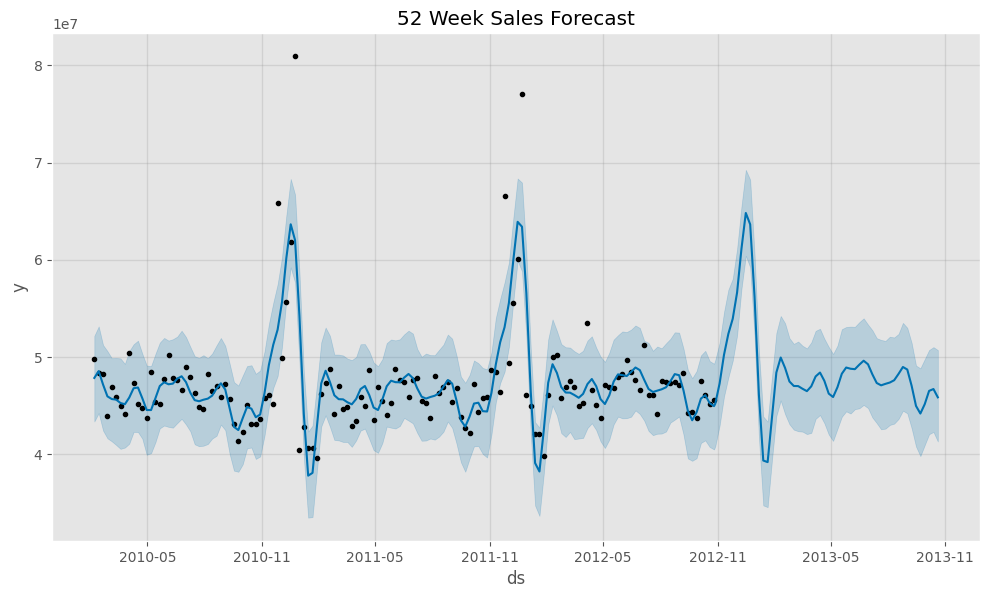

In [ ]:
fig = model.plot(forecast)
plt.title("52 Week Sales Forecast")
plt.show()

In [ ]:
forecast[['ds','yhat']].tail(52)['yhat'].sum()

np.float64(2525519477.552402)

In [ ]:
current_sales = forecast_df['y'].sum()
future_sales = forecast.tail(52)['yhat'].sum()

growth = ((future_sales - current_sales) / current_sales) * 100

print(f"Current Sales : {current_sales:,.2f}")
print(f"Forecast Sales: {future_sales:,.2f}")
print(f"Growth %      : {growth:.2f}%")

Current Sales : 6,737,218,987.11
Forecast Sales: 2,525,519,477.55
Growth %      : -62.51%


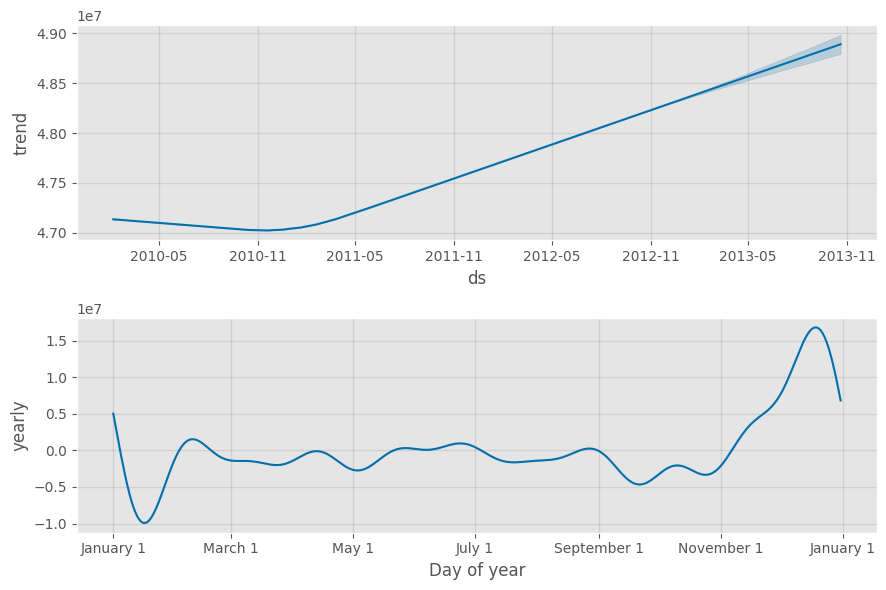

In [ ]:
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
store_sales = (
    df.groupby('Store')['Weekly_Sales']
      .sum()
      .sort_values(ascending=False)
)

store_sales.head(10)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


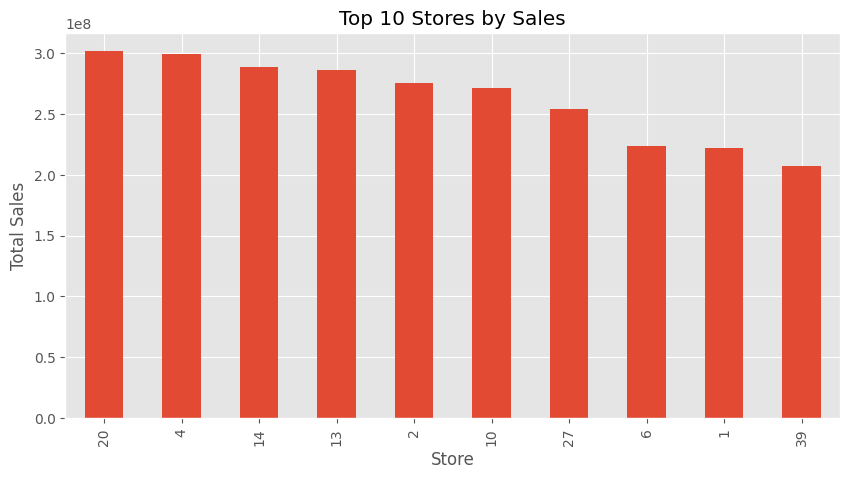

In [ ]:
top10 = store_sales.head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')

plt.title('Top 10 Stores by Sales')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
store_sales.tail(10)

,Weekly_Sales
Store,
29,77141554.31
16,74252425.40
37,74202740.32
30,62716885.12
3,57586735.07
38,55159626.42
36,53412214.97
5,45475688.90
44,43293087.84


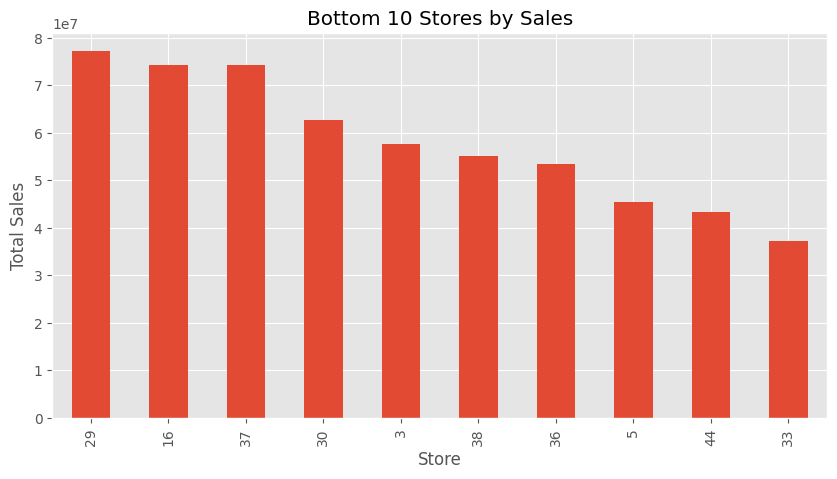

In [ ]:
bottom10 = store_sales.tail(10)

plt.figure(figsize=(10,5))
bottom10.plot(kind='bar')

plt.title('Bottom 10 Stores by Sales')
plt.ylabel('Total Sales')
plt.show()

**Business Recommendations**

1. Focus inventory planning before holiday seasons.
2. Replicate strategies of top-performing stores.
3. Monitor unemployment trends for demand forecasting.
4. Use forecasting model for staffing and inventory decisions.
5. Optimize low-performing stores using cluster analysis.